In [ ]:
# Cell 1: Install dependencies
!pip install h5py matplotlib numpy torch torchvision tqdm -q
print('Dependencies installed.')

Dependencies installed.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# ── Cell 1: Install ───────────────────────────────────────────────────────────
!pip install git+https://github.com/Blealtan/efficient-kan.git -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# Cell 2: Imports and reproducibility
import os, gc, glob, time, json, math, random, warnings
import numpy as np
import h5py
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from tqdm import tqdm
from efficient_kan import KAN

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cpu


In [ ]:
# Cell 3: Global config
BASE_DIR    = '/content/drive/MyDrive/gray_scott_data'
TRAIN_FILES = [
    f'{BASE_DIR}/train/maze_train.hdf5',
    f'{BASE_DIR}/train/maze_train_10.hdf5',
]
VAL_FILE   = f'{BASE_DIR}/val/maze_val.hdf5'
TEST_FILE  = f'{BASE_DIR}/test/maze_test.hdf5'
CKPT_DIR   = f'{BASE_DIR}/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
BEST_CKPT   = f'{CKPT_DIR}/dual_fno_kan_best.pt'
LATEST_CKPT = f'{CKPT_DIR}/dual_fno_kan_latest.pt'

# Architecture
WIDTH        = 32
MODES        = 10
N_FNO_LAYERS = 5
KAN_HIDDEN   = 24
KAN_GRID     = 5
KAN_ORDER    = 3

# Training
BATCH_TRAIN  = 4
BATCH_EVAL   = 8
LR           = 1e-3
WEIGHT_DECAY = 1e-4
NUM_EPOCHS   = 150
PATIENCE     = 2
SPECTRAL_WT  = 0.1
NUM_WORKERS  = 2

print('Config loaded.')
print(f'  FNO: {N_FNO_LAYERS} layers | width={WIDTH} | modes={MODES}')
print(f'  KAN latent dim: {WIDTH*MODES*MODES}')

Config loaded.
  FNO: 5 layers | width=32 | modes=10
  KAN latent dim: 3200


In [ ]:
# Cell 4: HDF5 key inspector -- CRITICAL: run before any training
# A VRMSE > 1.0 almost always means data is not loading correctly.
# This cell prints every key so we know the exact schema.

def inspect_hdf5(path, label=''):
    print(f'\n{"="*55}')
    print(f'  {label}  -->  {path}')
    print(f'{"="*55}')
    if not os.path.exists(path):
        print('  [MISSING] File not found!')
        return
    with h5py.File(path, 'r') as f:
        def visitor(name, obj):
            indent = '  ' * (name.count('/') + 1)
            if isinstance(obj, h5py.Dataset):
                print(f'{indent}[Dataset] {name}: shape={obj.shape}, dtype={obj.dtype}')
            elif isinstance(obj, h5py.Group):
                print(f'{indent}[Group]   {name}/')
        print('  Attributes:')
        for k, v in f.attrs.items():
            print(f'    {k}: {v}')
        print('  Structure:')
        f.visititems(visitor)

for path, label in [
    (TRAIN_FILES[0], 'TRAIN file 0'),
    (TRAIN_FILES[1], 'TRAIN file 1'),
    (VAL_FILE,       'VAL file'),
    (TEST_FILE,      'TEST file'),
]:
    inspect_hdf5(path, label)

print('\nSCHEMA CHECK COMPLETE -- update keys in GrayScottDataset if needed.')



  TRAIN file 0  -->  /content/drive/MyDrive/gray_scott_data/train/maze_train.hdf5
  Attributes:
    n_pairs: 5000
    n_traj: 5
    regime: maze
    split: train
    timesteps_per_traj: 1000
  Structure:
  [Dataset] inputs: shape=(5000, 1, 128, 128, 2), dtype=float32
  [Dataset] targets: shape=(5000, 1, 128, 128, 2), dtype=float32

  TRAIN file 1  -->  /content/drive/MyDrive/gray_scott_data/train/maze_train_10.hdf5
  Attributes:
    end_pair: 10000
    n_pairs: 5000
    regime: maze
    split: train
    start_pair: 5000
    traj_end: 9
    traj_start: 5
  Structure:
  [Dataset] inputs: shape=(5000, 1, 128, 128, 2), dtype=float32
  [Dataset] targets: shape=(5000, 1, 128, 128, 2), dtype=float32

  VAL file  -->  /content/drive/MyDrive/gray_scott_data/val/maze_val.hdf5
  Attributes:
    end_pair: 2000
    n_pairs: 2000
    regime: maze
    split: valid
    start_pair: 0
    traj_end: 1
    traj_start: 0
  Structure:
  [Dataset] inputs: shape=(2000, 1, 128, 128, 2), dtype=float32
  [Datas

In [ ]:
# Cell 5: Dataset class -- lazy HDF5, unified normalisation
# Auto-detects three HDF5 schemas used by the Well:
#   Schema A: 'inputs' / 'targets'               (pre-processed pair files)
#   Schema B: 'input_fields' / 'output_fields'   (Well native)
#   Schema C: 't0_fields/A' + 't0_fields/B'      (raw Well trajectories)
# IMPORTANT: same norm stats applied to both input and target.

class GrayScottDataset(Dataset):
    SCHEMA_PAIR = 'pair'
    SCHEMA_RAW  = 'raw'

    def __init__(self, path, norm_stats=None, compute_stats=False):
        self.path = path
        self._fh  = None

        with h5py.File(path, 'r') as f:
            keys = list(f.keys())
            if 'inputs' in keys:
                self.schema = self.SCHEMA_PAIR
                self.in_key, self.out_key = 'inputs', 'targets'
                self.n = f['inputs'].shape[0]
            elif 'input_fields' in keys:
                self.schema = self.SCHEMA_PAIR
                self.in_key, self.out_key = 'input_fields', 'output_fields'
                self.n = f['input_fields'].shape[0]
            elif 't0_fields' in keys:
                self.schema = self.SCHEMA_RAW
                self.in_key = 't0_fields'
                n_traj = f['t0_fields']['A'].shape[0]
                n_t    = f['t0_fields']['A'].shape[1]
                self.n = n_traj * (n_t - 1)
                self._n_traj, self._n_t = n_traj, n_t
            else:
                raise ValueError(f'Unknown HDF5 schema. Keys: {keys}')

        print(f'  [{path.split("/")[-1]}] schema={self.schema}, n={self.n:,}')

        if compute_stats:
            self.norm = self._compute_stats()
        elif norm_stats is not None:
            self.norm = norm_stats
        else:
            self.norm = {'mean': np.zeros((2,1,1), dtype=np.float32),
                         'std':  np.ones( (2,1,1), dtype=np.float32)}

    def _open(self):
        if self._fh is None:
            self._fh = h5py.File(self.path, 'r')

    def _to_chw(self, arr):
        arr = arr.astype(np.float32)
        if arr.ndim == 4 and arr.shape[0] == 1:  arr = arr[0]
        if arr.ndim == 3 and arr.shape[-1] == 2: arr = arr.transpose(2, 0, 1)
        return arr  # (2, H, W)

    def _normalize(self, arr):
        return (arr - self.norm['mean']) / (self.norm['std'] + 1e-8)

    def _compute_stats(self):
        print(f'    Computing norm stats for {self.path} ...')
        ch_sum  = np.zeros(2, dtype=np.float64)
        ch_sum2 = np.zeros(2, dtype=np.float64)
        count   = 0
        step    = max(1, self.n // 500)
        with h5py.File(self.path, 'r') as f:
            for i in range(0, self.n, step):
                x = self._get_input_raw(f, i)
                ch_sum  += x.reshape(2, -1).sum(axis=1)
                ch_sum2 += (x.reshape(2, -1)**2).sum(axis=1)
                count   += x.shape[1] * x.shape[2]
        mean = (ch_sum  / count).astype(np.float32)
        std  = np.sqrt(np.maximum(ch_sum2/count - (ch_sum/count)**2, 1e-12)).astype(np.float32)
        print(f'    Ch A  mean={mean[0]:.4f}  std={std[0]:.4f}')
        print(f'    Ch B  mean={mean[1]:.4f}  std={std[1]:.4f}')
        return {'mean': mean[:,None,None], 'std': std[:,None,None]}

    def _get_input_raw(self, fh, idx):
        if self.schema == self.SCHEMA_PAIR:
            return self._to_chw(fh[self.in_key][idx])
        traj = idx // (self._n_t - 1)
        t    = idx  % (self._n_t - 1)
        A = fh['t0_fields']['A'][traj, t]
        B = fh['t0_fields']['B'][traj, t]
        return np.stack([A, B], axis=0).astype(np.float32)

    def _get_target_raw(self, fh, idx):
        if self.schema == self.SCHEMA_PAIR:
            return self._to_chw(fh[self.out_key][idx])
        traj = idx // (self._n_t - 1)
        t    = idx  % (self._n_t - 1) + 1
        A = fh['t0_fields']['A'][traj, t]
        B = fh['t0_fields']['B'][traj, t]
        return np.stack([A, B], axis=0).astype(np.float32)

    def __len__(self): return self.n

    def __getitem__(self, idx):
        self._open()
        x = self._normalize(self._get_input_raw(self._fh,  idx))
        y = self._normalize(self._get_target_raw(self._fh, idx))
        return {'input':  torch.from_numpy(x),
                'target': torch.from_numpy(y)}

    def __del__(self):
        if self._fh is not None:
            try: self._fh.close()
            except: pass


In [ ]:
# Cell 6: Build datasets and DataLoaders
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

print('Computing norm stats from training data ...')
ds_stat    = GrayScottDataset(TRAIN_FILES[0], compute_stats=True)
norm_stats = ds_stat.norm
del ds_stat; gc.collect()

print('Building datasets ...')
train_ds = ConcatDataset([
    GrayScottDataset(p, norm_stats=norm_stats) for p in TRAIN_FILES
])
val_ds   = GrayScottDataset(VAL_FILE,  norm_stats=norm_stats)
test_ds  = GrayScottDataset(TEST_FILE, norm_stats=norm_stats)

print(f'Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}')

def collate(batch):
    return {k: torch.stack([b[k] for b in batch]) for k in batch[0]}

train_loader = DataLoader(train_ds, batch_size=BATCH_TRAIN, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'),
    drop_last=True, collate_fn=collate)
val_loader   = DataLoader(val_ds, batch_size=BATCH_EVAL, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'), collate_fn=collate)
test_loader  = DataLoader(test_ds, batch_size=BATCH_EVAL, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'), collate_fn=collate)

# Sanity check
batch = next(iter(train_loader))
print(f'Batch input : {batch["input"].shape}  range [{batch["input"].min():.3f}, {batch["input"].max():.3f}]')
print(f'Batch target: {batch["target"].shape}  range [{batch["target"].min():.3f}, {batch["target"].max():.3f}]')
assert not torch.isnan(batch['input']).any(),  'NaN in inputs!'
assert not torch.isnan(batch['target']).any(), 'NaN in targets!'
print('No NaNs detected -- data pipeline OK.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Computing norm stats from training data ...
  [maze_train.hdf5] schema=pair, n=5,000
    Computing norm stats for /content/drive/MyDrive/gray_scott_data/train/maze_train.hdf5 ...
    Ch A  mean=0.5292  std=0.1636
    Ch B  mean=0.1594  std=0.1002
Building datasets ...
  [maze_train.hdf5] schema=pair, n=5,000
  [maze_train_10.hdf5] schema=pair, n=5,000
  [maze_val.hdf5] schema=pair, n=2,000
  [maze_test.hdf5] schema=pair, n=2,000
Train: 10,000  Val: 2,000  Test: 2,000
Batch input : torch.Size([4, 2, 128, 128])  range [-1.636, 2.249]
Batch target: torch.Size([4, 2, 128, 128])  range [-1.641, 2.227]
No NaNs detected -- data pipeline OK.


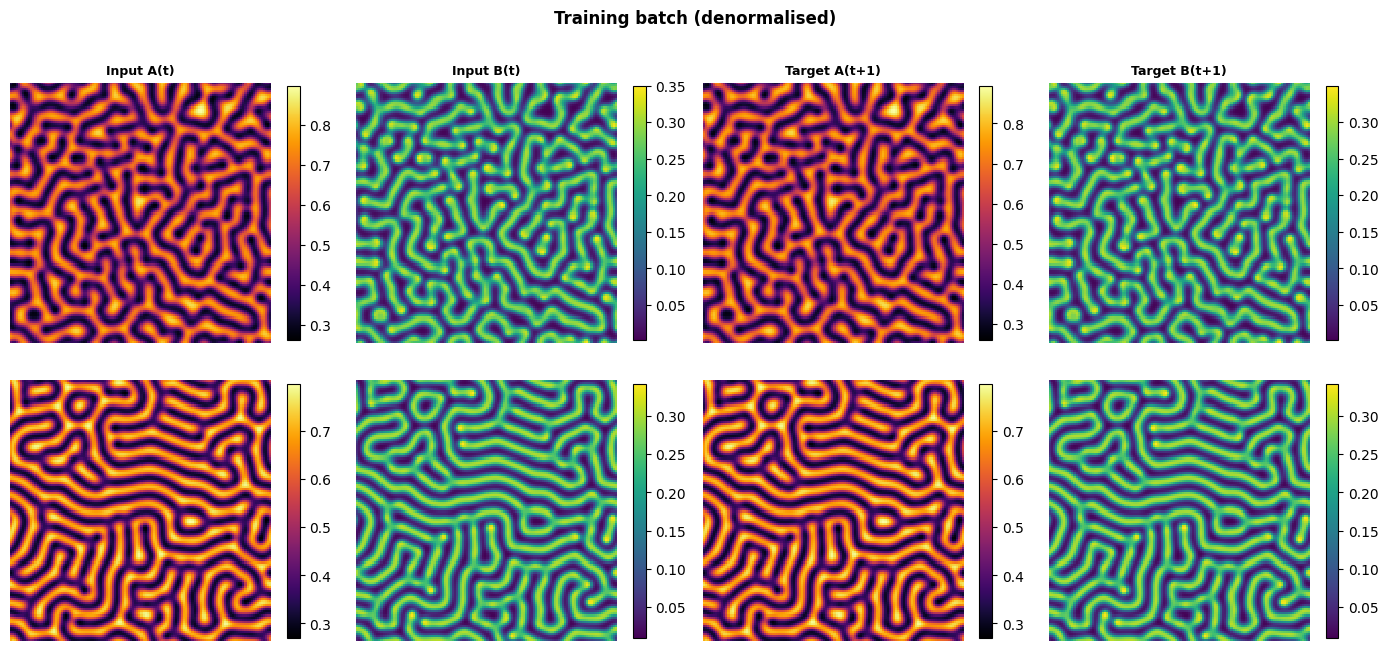

In [ ]:
# Cell 7: Visualise a training batch
def plot_batch(batch, norm, n=2):
    inp = batch['input'].numpy()
    tgt = batch['target'].numpy()
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.5*n))
    fig.suptitle('Training batch (denormalised)', fontsize=12, fontweight='bold')
    cols  = ['Input A(t)', 'Input B(t)', 'Target A(t+1)', 'Target B(t+1)']
    cmaps = ['inferno', 'viridis', 'inferno', 'viridis']
    for i in range(n):
        xi = inp[i] * norm['std'] + norm['mean']
        yi = tgt[i] * norm['std'] + norm['mean']
        for j, (field, cmap) in enumerate(zip([xi[0],xi[1],yi[0],yi[1]], cmaps)):
            ax = axes[i, j]
            im = ax.imshow(field, cmap=cmap, interpolation='nearest')
            plt.colorbar(im, ax=ax, shrink=0.75)
            if i == 0: ax.set_title(cols[j], fontsize=9, fontweight='bold')
            ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'{BASE_DIR}/sample_batch.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_batch(batch, norm_stats)


In [ ]:
# Cell 8: Model -- Dual-Domain FNO-KAN
#
# Architecture (KANO dual-domain principle):
#   INPUT (B,2,128,128)
#     -> Lifting Conv1x1 -> (B, WIDTH, 128,128)
#     -> 5x FNO layers with U-Net skip connections
#     -> (B, WIDTH, 128,128)
#     |-- PATH A (spectral): rfft2 -> K modes -> KAN -> irfft2
#     |-- PATH B (spatial) : depthwise Conv3x3
#     -> ADD paths
#     -> Output projection Conv1x1 -> (B, 2, 128,128)
#
# Design rationale:
#   1. KAN placed ONCE as a wide shallow head (not interleaved per FNO layer).
#      Shallow-wide KAN > deep-narrow KAN for PDEs (ICLR 2025 KAN paper).
#   2. U-Net skips between FNO blocks preserve local high-frequency content
#      (maze wall edges) that global spectral layers blur out.
#   3. Dual-domain head: spectral KAN + spatial depthwise conv -- each
#      component operates in the basis where it is naturally sparse.
#   4. Single norm stats for both input and target (same physical field).

class SpectralConv2d(nn.Module):
    """FNO spectral convolution -- positive modes only, ortho FFT."""
    def __init__(self, in_ch, out_ch, modes):
        super().__init__()
        self.modes = modes
        scale = 1.0 / (in_ch * out_ch)
        self.weight = nn.Parameter(
            scale * torch.randn(in_ch, out_ch, modes, modes, dtype=torch.cfloat)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        x_ft   = torch.fft.rfft2(x, norm='ortho')
        out_ft = torch.zeros(B, self.weight.shape[1], H, W//2+1,
                             dtype=torch.cfloat, device=x.device)
        K = self.modes
        out_ft[:, :, :K, :K] = torch.einsum(
            'bixy,ioky->boky',
            x_ft[:, :, :K, :K],
            self.weight.permute(0, 1, 3, 2)
        )
        return torch.fft.irfft2(out_ft, s=(H, W), norm='ortho')


class FNOBlock(nn.Module):
    """One FNO layer: spectral conv + bypass -> GELU + GroupNorm."""
    def __init__(self, width, modes):
        super().__init__()
        self.spectral = SpectralConv2d(width, width, modes)
        self.bypass   = nn.Conv2d(width, width, kernel_size=1)
        self.norm     = nn.GroupNorm(min(8, width), width)

    def forward(self, x):
        return F.gelu(self.norm(self.spectral(x) + self.bypass(x)))


class DualDomainKANHead(nn.Module):
    """
    Dual-domain reaction operator:
      PATH A -- spectral: FFT -> K modes -> flatten -> KAN -> reshape -> IFFT
      PATH B -- spatial : depthwise Conv3x3 + pointwise Conv1x1
      Output = gate_a * PATH_A + gate_b * PATH_B
    """
    def __init__(self, width, modes, kan_hidden, kan_grid, kan_order):
        super().__init__()
        self.width = width
        self.modes = modes
        latent     = width * modes * modes

        # PATH A: KAN in spectral latent space
        self.kan = KAN(
            layers_hidden=[latent, kan_hidden, latent],
            grid_size=kan_grid,
            spline_order=kan_order,
            scale_noise=0.05,
            scale_base=1.0,
            scale_spline=1.0,
            base_activation=nn.SiLU,
            grid_eps=0.02,
            grid_range=[-1.5, 1.5],
        )

        # PATH B: depthwise + pointwise spatial conv
        self.spatial = nn.Sequential(
            nn.Conv2d(width, width, kernel_size=3, padding=1,
                      groups=width, bias=False),
            nn.Conv2d(width, width, kernel_size=1, bias=True),
            nn.GroupNorm(min(8, width), width),
        )

        # Learnable gating -- gate_a starts near 0 (stable init)
        self.gate_a = nn.Parameter(torch.zeros(1))
        self.gate_b = nn.Parameter(torch.ones(1))

    def forward(self, x):
        B, W, H, Sp = x.shape
        K = self.modes

        # PATH A: spectral KAN
        x_ft    = torch.fft.rfft2(x, norm='ortho')
        trunc   = x_ft[:, :, :K, :K].real
        latent  = torch.clamp(trunc.reshape(B, -1), -3.0, 3.0)
        out_lat = self.kan(latent)
        out_trunc = out_lat.reshape(B, W, K, K)
        out_ft  = torch.zeros_like(x_ft)
        out_ft[:, :, :K, :K] = torch.complex(out_trunc, torch.zeros_like(out_trunc))
        path_a  = torch.fft.irfft2(out_ft, s=(H, Sp), norm='ortho')

        # PATH B: spatial conv
        path_b = self.spatial(x)

        return torch.tanh(self.gate_a) * path_a + self.gate_b * path_b


class DualDomainFNOKAN(nn.Module):
    """
    Dual-Domain FNO-KAN surrogate for Gray-Scott reaction-diffusion.
    Input : (B, 2, H, W) normalised
    Output: (B, 2, H, W) predicted next step
    """
    def __init__(self, width=WIDTH, modes=MODES, n_layers=N_FNO_LAYERS,
                 kan_hidden=KAN_HIDDEN, kan_grid=KAN_GRID, kan_order=KAN_ORDER):
        super().__init__()
        self.width = width; self.modes = modes

        self.lifting    = nn.Conv2d(2, width, kernel_size=1)
        self.fno_layers = nn.ModuleList([FNOBlock(width, modes) for _ in range(n_layers)])

        # U-Net skip merge projections for encoder-decoder symmetric pairs
        self.n_skip     = n_layers // 2   # 2 for n_layers=5
        self.skip_projs = nn.ModuleList([
            nn.Conv2d(2*width, width, kernel_size=1) for _ in range(self.n_skip)
        ])

        self.dual_head = DualDomainKANHead(width, modes, kan_hidden, kan_grid, kan_order)
        self.proj1     = nn.Conv2d(width, 128, kernel_size=1)
        self.proj2     = nn.Conv2d(128,   2,   kernel_size=1)
        self._init_weights()

    def _init_weights(self):
        for m in [self.lifting, self.proj1, self.proj2]:
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None: nn.init.zeros_(m.bias)
        for m in self.skip_projs:
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.lifting(x)
        n = len(self.fno_layers)
        skips = {}

        # Encoder half: save skip activations
        for i in range(self.n_skip):
            x = self.fno_layers[i](x)
            skips[i] = x

        # Bottleneck
        x = self.fno_layers[self.n_skip](x)

        # Decoder half: merge with skips (U-Net style)
        for j in range(self.n_skip - 1, -1, -1):
            x = self.fno_layers[n - 1 - j](x)
            x = self.skip_projs[self.n_skip - 1 - j](
                torch.cat([x, skips[j]], dim=1)
            )

        x = self.dual_head(x)
        x = F.gelu(self.proj1(x))
        return self.proj2(x)


# Instantiate and verify
model = DualDomainFNOKAN().to(DEVICE)
total_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_p:,}')
components = {
    'Lifting'       : sum(p.numel() for p in model.lifting.parameters()),
    'FNO layers'    : sum(p.numel() for p in model.fno_layers.parameters()),
    'Skip projs'    : sum(p.numel() for p in model.skip_projs.parameters()),
    'Dual KAN head' : sum(p.numel() for p in model.dual_head.parameters()),
    'Output proj'   : (sum(p.numel() for p in model.proj1.parameters()) +
                       sum(p.numel() for p in model.proj2.parameters())),
}
for k, v in components.items():
    print(f'  {k:<20}: {v:>10,}  ({100*v/total_p:.1f}%)')

with torch.no_grad():
    dummy = torch.randn(2, 2, 128, 128).to(DEVICE)
    out   = model(dummy)
    print(f'Dry run  {tuple(dummy.shape)} -> {tuple(out.shape)}')
    assert out.shape == dummy.shape
    assert not torch.isnan(out).any(), 'NaN in output!'
    print('Shape and NaN checks passed.')


Total trainable parameters: 2,063,748
  Lifting             :         96  (0.0%)
  FNO layers          :    517,600  (25.1%)
  Skip projs          :      4,160  (0.2%)
  Dual KAN head       :  1,537,410  (74.5%)
  Output proj         :      4,482  (0.2%)
Dry run  (2, 2, 128, 128) -> (2, 2, 128, 128)
Shape and NaN checks passed.


In [ ]:
# Cell 9: Loss functions

def relative_l2(pred, target):
    B     = pred.shape[0]
    diff  = (pred - target).reshape(B, -1)
    denom = target.reshape(B, -1).norm(dim=1) + 1e-8
    return (diff.norm(dim=1) / denom).mean()


def spectral_loss(pred, target):
    pred_ft   = torch.fft.rfft2(pred,   norm='ortho').abs()
    target_ft = torch.fft.rfft2(target, norm='ortho').abs()
    return relative_l2(pred_ft, target_ft)


def combined_loss(pred, target, alpha=SPECTRAL_WT):
    rl2  = relative_l2(pred, target)
    spec = spectral_loss(pred, target)
    return rl2 + alpha * spec, rl2, spec


# Verify
with torch.no_grad():
    p = torch.randn(4, 2, 128, 128)
    t = torch.randn(4, 2, 128, 128)
    tot, rl2, spec = combined_loss(p, t)
    print(f'Loss test  total={tot:.4f}  rl2={rl2:.4f}  spec={spec:.4f}')
    tot2, rl2_2, _ = combined_loss(t, t)
    print(f'Identical tensors: total={tot2:.6f}  rl2={rl2_2:.6f} (should be ~0)')


Loss test  total=1.4769  rl2=1.4114  spec=0.6552
Identical tensors: total=0.000000  rl2=0.000000 (should be ~0)


In [ ]:
# Cell 10: Checkpoint helpers

def save_ckpt(path, epoch, model, optimizer, scheduler,
              best_val, no_improve, history, label):
    torch.save({
        'model_state'    : model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'epoch'          : epoch,
        'best_val'       : best_val,
        'no_improve'     : no_improve,
        'history'        : history,
        'label'          : label,
        'torch_rng'      : torch.get_rng_state(),
        'numpy_rng'      : np.random.get_state(),
    }, path)


def load_ckpt(path, model, optimizer, scheduler):
    ck = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ck['model_state'])
    optimizer.load_state_dict(ck['optimizer_state'])
    scheduler.load_state_dict(ck['scheduler_state'])
    for state in optimizer.state.values():
        for k, v in state.items():
            if isinstance(v, torch.Tensor):
                state[k] = v.to(DEVICE)
    #torch.set_rng_state(ck['torch_rng'])
    #np.random.set_state(ck['numpy_rng'])
    return ck['epoch'] + 1, ck['best_val'], ck['no_improve'], ck['history']


def epoch_ckpt_path(ep):
    return f'{CKPT_DIR}/dual_fno_kan_epoch_{ep:03d}.pt'


print('Checkpoint helpers defined.')


Checkpoint helpers defined.


In [ ]:
# Cell 11: Training and validation loop

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    tot_rl2 = tot_spec = n = 0.0
    for batch in loader:
        x = batch['input'].to(DEVICE,  non_blocking=True)
        y = batch['target'].to(DEVICE, non_blocking=True)
        _, rl2, spec = combined_loss(model(x), y)
        bs = x.size(0)
        tot_rl2  += rl2.item()  * bs
        tot_spec += spec.item() * bs
        n        += bs
    return tot_rl2 / n, tot_spec / n


def train_one_epoch(model, loader, optimizer):
    model.train()
    tot_rl2 = tot_spec = n = 0.0
    for batch in tqdm(loader, desc='  train', leave=False):
        x = batch['input'].to(DEVICE,  non_blocking=True)
        y = batch['target'].to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        pred = model(x)
        loss, rl2, spec = combined_loss(pred, y)
        if torch.isnan(loss):
            print('  WARNING: NaN loss -- skipping batch')
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        bs = x.size(0)
        tot_rl2  += rl2.item()  * bs
        tot_spec += spec.item() * bs
        n        += bs
    return tot_rl2 / n, tot_spec / n


def run_training(model, train_loader, val_loader, label='DualFNOKAN', resume=False):
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999)
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
    )

    if resume and os.path.exists(LATEST_CKPT):
        print(f'  Resuming from {LATEST_CKPT}')
        start, best_val, no_improve, history = load_ckpt(
            LATEST_CKPT, model, optimizer, scheduler
        )
        print(f'  Resumed at epoch {start} | best_val={best_val:.4f}')
    else:
        if resume: print('  No checkpoint found -- starting fresh.')
        start, best_val, no_improve = 0, float('inf'), 0
        history = {'tr_rl2':[], 'tr_spec':[], 'va_rl2':[], 'va_spec':[], 'lr':[]}

    best_state = None

    for epoch in range(start, NUM_EPOCHS):
        t0 = time.time()
        tr_rl2, tr_spec = train_one_epoch(model, train_loader, optimizer)
        va_rl2, va_spec = evaluate(model, val_loader)
        scheduler.step()
        lr_now = optimizer.param_groups[0]['lr']

        history['tr_rl2'].append(tr_rl2);  history['tr_spec'].append(tr_spec)
        history['va_rl2'].append(va_rl2);  history['va_spec'].append(va_spec)
        history['lr'].append(lr_now)

        is_best = va_rl2 < best_val
        marker  = ' *BEST*' if is_best else f'  [no improve {no_improve+1}/{PATIENCE}]'

        if is_best:
            best_val   = va_rl2
            no_improve = 0
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
            save_ckpt(BEST_CKPT, epoch, model, optimizer, scheduler,
                      best_val, no_improve, history, label)
        else:
            no_improve += 1

        # Save per-epoch checkpoint (full resume state)
        save_ckpt(epoch_ckpt_path(epoch+1), epoch, model, optimizer, scheduler,
                  best_val, no_improve, history, label)
        # Always overwrite latest (single file for fast resume)
        save_ckpt(LATEST_CKPT, epoch, model, optimizer, scheduler,
                  best_val, no_improve, history, label)

        elapsed = time.time() - t0
        print(f'[{label}] E{epoch+1:03d} | '
              f'tr_rl2={tr_rl2:.4f} tr_spec={tr_spec:.4f} | '
              f'va_rl2={va_rl2:.4f} | best={best_val:.4f} | '
              f'lr={lr_now:.2e} | {elapsed:.1f}s{marker}')

        if no_improve >= PATIENCE:
            print(f'\n  Early stopping at epoch {epoch+1} (best={best_val:.4f})')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    elif os.path.exists(BEST_CKPT):
        ck = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ck['model_state'])

    print(f'\n[{label}] Done. Best val rl2 = {best_val:.4f}')
    return model, history, best_val


print('Training loop defined.')


Training loop defined.


In [ ]:
# Cell 12: LAUNCH TRAINING (fresh start)
# If runtime disconnects, skip this cell and run Cell 13 instead.
print('='*60)
print('Training: Dual-Domain FNO-KAN')
print('='*60)

model = DualDomainFNOKAN().to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

model, history, best_val = run_training(
    model, train_loader, val_loader, label='DualFNOKAN', resume=False
)


Training: Dual-Domain FNO-KAN
Parameters: 2,063,748


[DualFNOKAN] E001 | tr_rl2=0.0291 tr_spec=0.0277 | va_rl2=0.0203 | best=0.0203 | lr=1.00e-03 | 1319.9s *BEST*


[DualFNOKAN] E002 | tr_rl2=0.0166 tr_spec=0.0162 | va_rl2=0.0162 | best=0.0162 | lr=1.00e-03 | 1348.1s *BEST*


[DualFNOKAN] E003 | tr_rl2=0.0127 tr_spec=0.0123 | va_rl2=0.0154 | best=0.0154 | lr=9.99e-04 | 1365.5s *BEST*


[DualFNOKAN] E004 | tr_rl2=0.0109 tr_spec=0.0108 | va_rl2=0.0136 | best=0.0136 | lr=9.98e-04 | 1331.2s *BEST*


...

[DualFNOKAN] E012 | tr_rl2=0.0063 tr_spec=0.0063 | va_rl2=0.0118 | best=0.0098 | lr=9.84e-04 | 1317.3s  [no improve 1/20]


[DualFNOKAN] E013 | tr_rl2=0.0062 tr_spec=0.0062 | va_rl2=0.0096 | best=0.0096 | lr=9.82e-04 | 1305.3s *BEST*


[DualFNOKAN] E014 | tr_rl2=0.0060 tr_spec=0.0061 | va_rl2=0.0113 | best=0.0096 | lr=9.79e-04 | 1342.8s  [no improve 1/20]


[DualFNOKAN] E015 | tr_rl2=0.0058 tr_spec=0.0059 | va_rl2=0.0097 | best=0.0096 | lr=9.76e-04 | 1347.0s  [no improve 2/20]


  train:  22%|██▏       | 547/2500 [04:09<13:25,  2.42it/s]

In [ ]:
# Cell 13: RESUME TRAINING after disconnect
# Re-run cells 1-11 first, then run this cell INSTEAD of Cell 12.

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

existing = sorted(glob.glob(f'{CKPT_DIR}/dual_fno_kan_epoch_*.pt'))
print(f'Found {len(existing)} epoch checkpoint(s) in {CKPT_DIR}')

if existing:
    info = torch.load(existing[-1], map_location='cpu',weights_only=False)
    last_ep     = info['epoch'] + 1
    best_so_far = info['best_val']
    print(f'  Last completed epoch : {last_ep}')
    print(f'  Best val rl2 so far  : {best_so_far:.4f}')
    print(f'  Epochs remaining     : {NUM_EPOCHS - last_ep}')

    if last_ep <= NUM_EPOCHS:
        print('  Training complete -- loading best weights only.')
        model = DualDomainFNOKAN().to(DEVICE)
        ck    = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ck['model_state'])
        history  = ck['history']
        best_val = ck['best_val']
    else:
        model = DualDomainFNOKAN().to(DEVICE)
        #model, history, best_val = run_training(
            #model, train_loader, val_loader, label='DualFNOKAN', resume=True
        #)
else:
    print('No checkpoints found -- starting fresh.')
    model = DualDomainFNOKAN().to(DEVICE)
    model, history, best_val = run_training(
        model, train_loader, val_loader, label='DualFNOKAN', resume=False
    )


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 34 epoch checkpoint(s) in /content/drive/MyDrive/gray_scott_data/checkpoints
  Last completed epoch : 34
  Best val rl2 so far  : 0.0075
  Epochs remaining     : 116
  Training complete -- loading best weights only.


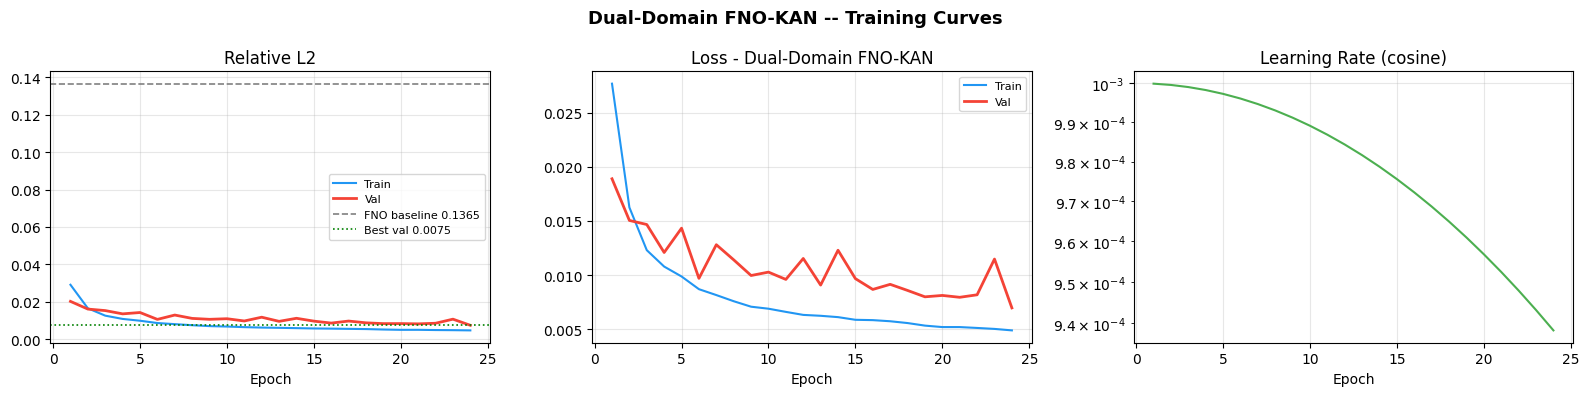

In [ ]:
# Cell 14: Training curves

def plot_training(history, best_val):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle('Dual-Domain FNO-KAN -- Training Curves', fontsize=13, fontweight='bold')
    epochs = range(1, len(history['tr_rl2']) + 1)

    axes[0].plot(epochs, history['tr_rl2'], label='Train', color='#2196F3', lw=1.5)
    axes[0].plot(epochs, history['va_rl2'], label='Val',   color='#F44336', lw=2.0)
    axes[0].axhline(0.1365,   color='gray',  ls='--', lw=1.2, label='FNO baseline 0.1365')
    axes[0].axhline(best_val, color='green', ls=':',  lw=1.2, label=f'Best val {best_val:.4f}')
    axes[0].set_title('Relative L2'); axes[0].set_xlabel('Epoch')
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['tr_spec'], label='Train', color='#2196F3', lw=1.5)
    axes[1].plot(epochs, history['va_spec'], label='Val',   color='#F44336', lw=2.0)
    axes[1].set_title('Loss - Dual-Domain FNO-KAN'); axes[1].set_xlabel('Epoch')
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    axes[2].semilogy(epochs, history['lr'], color='#4CAF50', lw=1.5)
    axes[2].set_title('Learning Rate (cosine)'); axes[2].set_xlabel('Epoch')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{BASE_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training(history, best_val)


In [ ]:
# Cell 15: Test evaluation

ck = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ck['model_state'])
print(f'Loaded best checkpoint (epoch {ck["epoch"]+1}  val_rl2={ck["best_val"]:.4f})')

def get_preds(model, loader, norm):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating'):
            x  = batch['input'].to(DEVICE)
            y  = batch['target']
            p  = model(x).cpu().numpy()
            preds.append(p * norm['std'] + norm['mean'])
            trues.append(y.numpy() * norm['std'] + norm['mean'])
    return np.concatenate(preds), np.concatenate(trues)


def compute_metrics(preds, trues):
    def vrmse(p, t):
        return np.sqrt(np.mean((p-t)**2)) / (np.std(t) + 1e-8)
    def rel_l2(p, t):
        return np.linalg.norm(p-t) / (np.linalg.norm(t) + 1e-8)
    return {
        'MSE'     : float(np.mean((preds-trues)**2)),
        'RMSE'    : float(np.sqrt(np.mean((preds-trues)**2))),
        'VRMSE'   : float(vrmse(preds, trues)),
        'VRMSE(A)': float(vrmse(preds[:,0], trues[:,0])),
        'VRMSE(B)': float(vrmse(preds[:,1], trues[:,1])),
        'Rel-L2'  : float(rel_l2(preds, trues)),
        'MAE'     : float(np.mean(np.abs(preds-trues))),
    }


test_preds, test_trues = get_preds(model, test_loader, norm_stats)
metrics = compute_metrics(test_preds, test_trues)

print('\n' + '='*50)
print('  TEST RESULTS -- Dual-Domain FNO-KAN')
print('='*50)
for k, v in metrics.items():
    print(f'  {k:<15} {v:>10.6f}')
print(f'\n  FNO baseline (official): 0.136500')
print(f'  Delta vs FNO baseline  : {metrics["VRMSE"] - 0.1365:+.6f}')


Loaded best checkpoint (epoch 24  val_rl2=0.0075)


Evaluating: 100%|██████████| 250/250 [06:39<00:00,  1.60s/it]



  TEST RESULTS -- Dual-Domain FNO-KAN
  MSE               0.000010
  RMSE              0.003167
  VRMSE             0.013562
  VRMSE(A)          0.023233
  VRMSE(B)          0.021378
  Rel-L2            0.007572
  MAE               0.000962

  FNO baseline (official): 0.136500
  Delta vs FNO baseline  : -0.122938


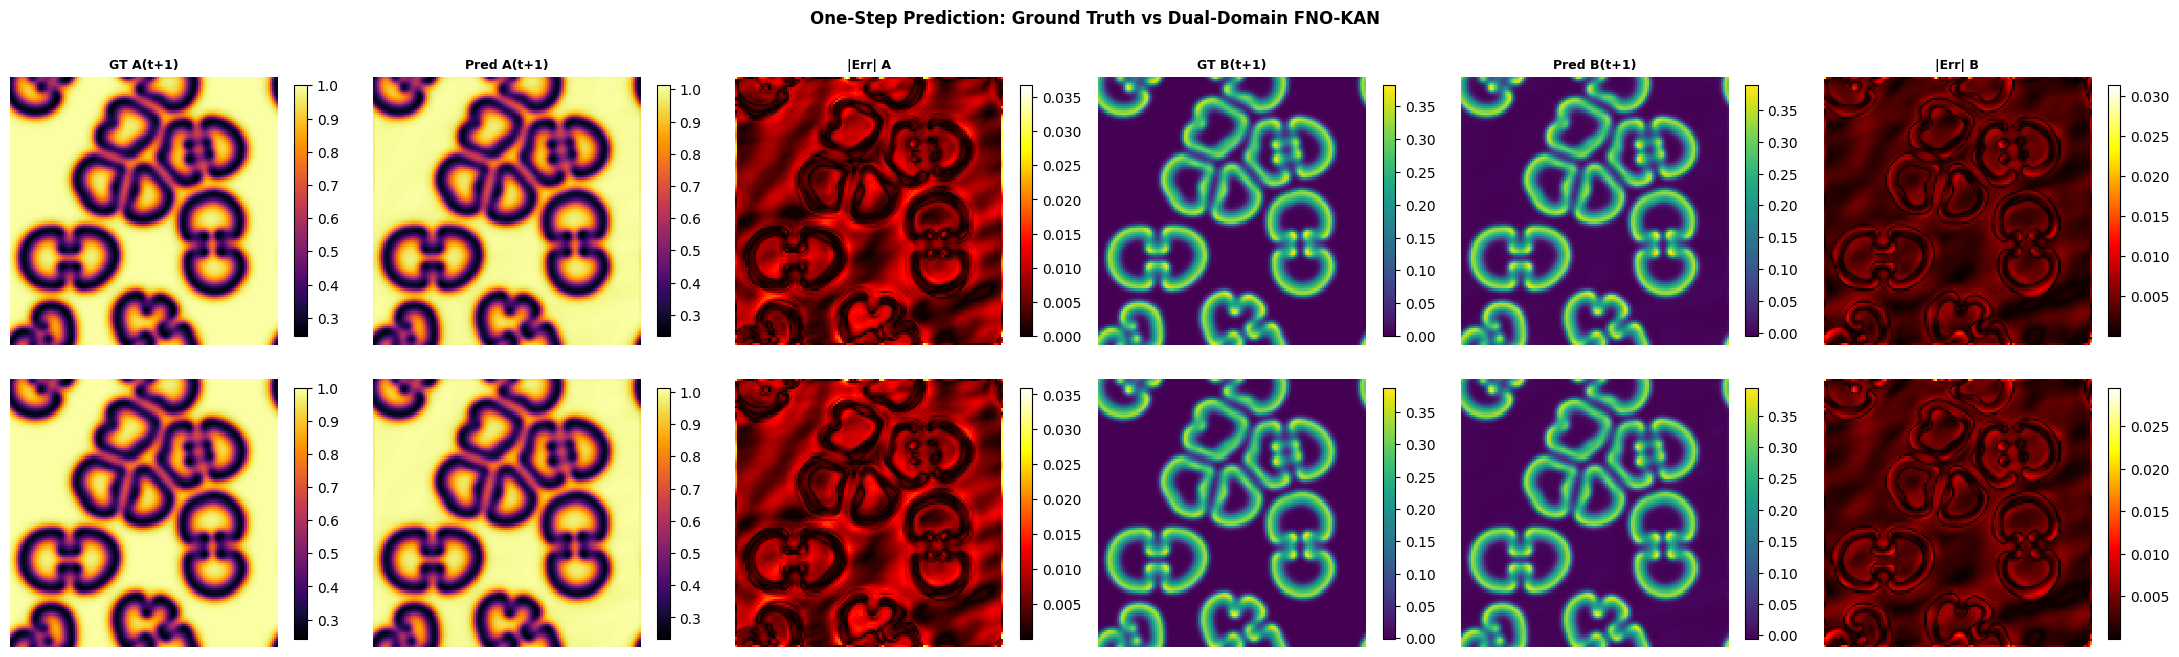

In [ ]:
# Cell 16: One-step prediction visualisation

def plot_predictions(preds, trues, n=2):
    fig, axes = plt.subplots(n, 6, figsize=(22, 3.5*n))
    fig.suptitle('One-Step Prediction: Ground Truth vs Dual-Domain FNO-KAN',
                 fontsize=12, fontweight='bold')
    cols  = ['GT A(t+1)', 'Pred A(t+1)', '|Err| A',
             'GT B(t+1)', 'Pred B(t+1)', '|Err| B']
    cmaps = ['inferno','inferno','hot','viridis','viridis','hot']
    for i in range(n):
        p = preds[i+40]; t = trues[i+40]
        fields = [t[0], p[0], np.abs(p[0]-t[0]),
                  t[1], p[1], np.abs(p[1]-t[1])]
        for j, (field, cmap) in enumerate(zip(fields, cmaps)):
            ax = axes[i, j]
            im = ax.imshow(field, cmap=cmap, interpolation='nearest')
            plt.colorbar(im, ax=ax, shrink=0.75)
            if i == 0: ax.set_title(cols[j], fontsize=9, fontweight='bold')
            ax.axis('off')
        sv = np.sqrt(np.mean((p-t)**2)) / (np.std(t)+1e-8)
        axes[i, 0].set_ylabel(f'VRMSE={sv:.4f}', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{BASE_DIR}/predictions.png', dpi=140, bbox_inches='tight')
    plt.show()

plot_predictions(test_preds, test_trues)


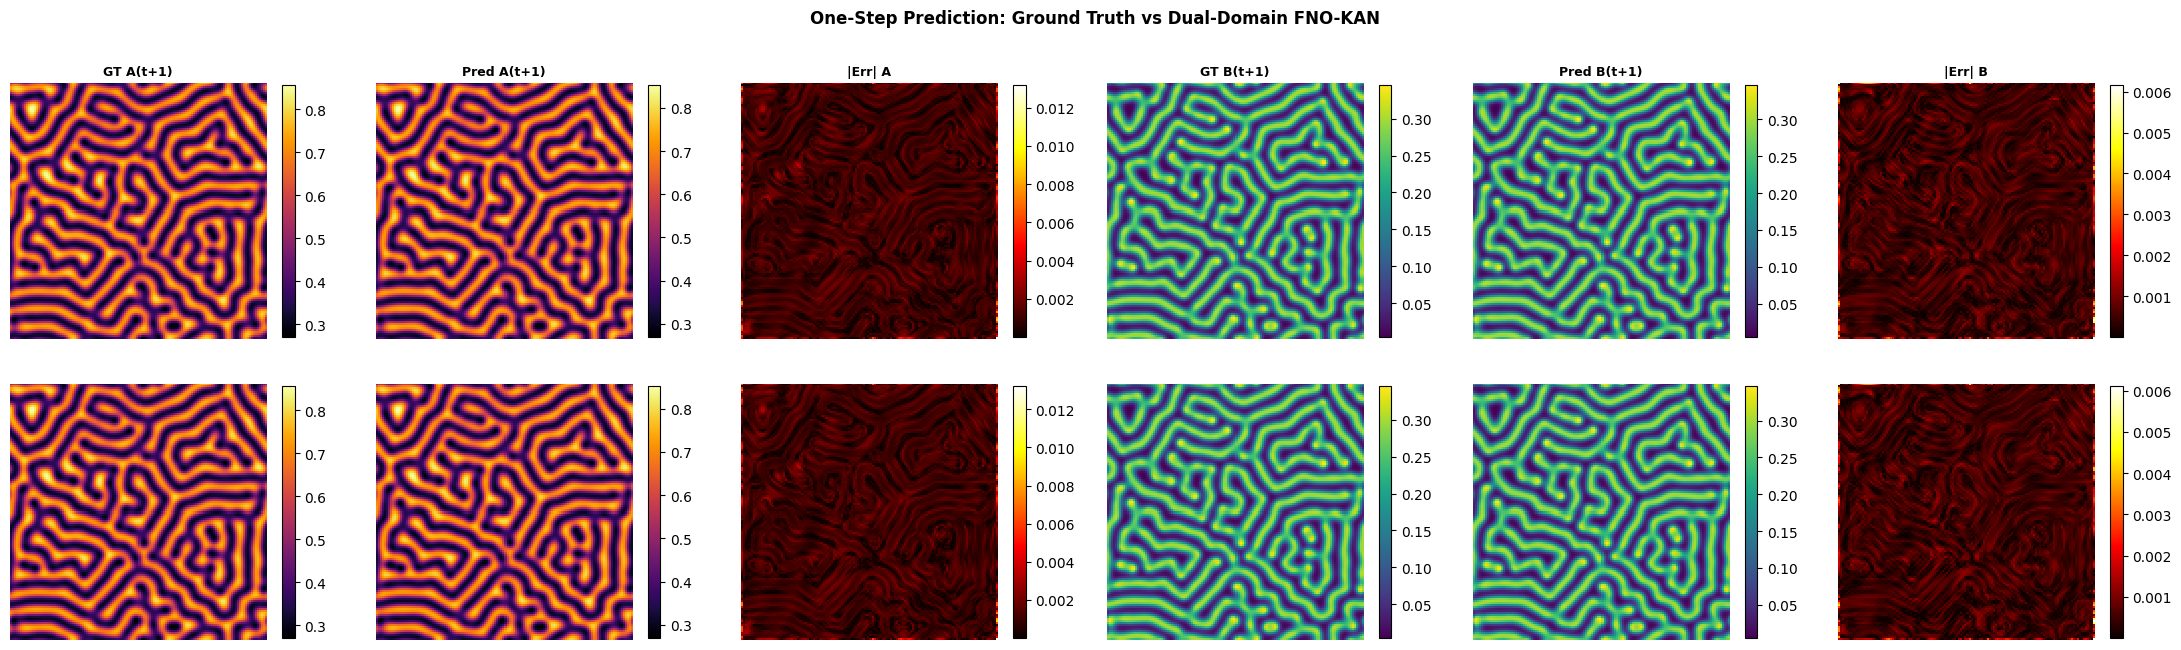

In [ ]:
# Cell 16: One-step prediction visualisation

def plot_predictions(preds, trues, n=2):
    fig, axes = plt.subplots(n, 6, figsize=(22, 3.5*n))
    fig.suptitle('One-Step Prediction: Ground Truth vs Dual-Domain FNO-KAN',
                 fontsize=12, fontweight='bold')
    cols  = ['GT A(t+1)', 'Pred A(t+1)', '|Err| A',
             'GT B(t+1)', 'Pred B(t+1)', '|Err| B']
    cmaps = ['inferno','inferno','hot','viridis','viridis','hot']
    for i in range(n):
        p = preds[i+200]; t = trues[i+200]
        fields = [t[0], p[0], np.abs(p[0]-t[0]),
                  t[1], p[1], np.abs(p[1]-t[1])]
        for j, (field, cmap) in enumerate(zip(fields, cmaps)):
            ax = axes[i, j]
            im = ax.imshow(field, cmap=cmap, interpolation='nearest')
            plt.colorbar(im, ax=ax, shrink=0.75)
            if i == 0: ax.set_title(cols[j], fontsize=9, fontweight='bold')
            ax.axis('off')
        sv = np.sqrt(np.mean((p-t)**2)) / (np.std(t)+1e-8)
        axes[i, 0].set_ylabel(f'VRMSE={sv:.4f}', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{BASE_DIR}/predictions.png', dpi=140, bbox_inches='tight')
    plt.show()

plot_predictions(test_preds, test_trues)


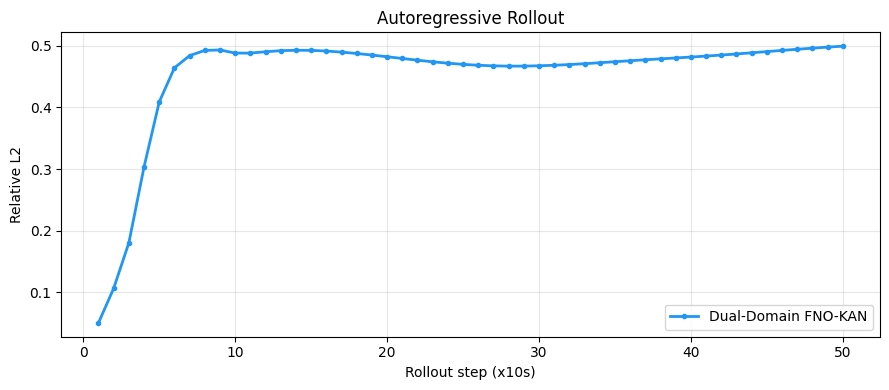

Steps below 0.5: 50/50
Final step error: 0.4996


In [ ]:
# Cell 17: Autoregressive rollout

@torch.no_grad()
def rollout(model, test_ds, norm, n_steps=50, traj_start=0):
    model.eval()
    mean_t = torch.from_numpy(norm['mean']).to(DEVICE)
    std_t  = torch.from_numpy(norm['std']).to(DEVICE)

    gt_frames = [test_ds[traj_start + s]['input'] for s in range(n_steps + 1)]
    gt = torch.stack(gt_frames).to(DEVICE)

    x_cur  = gt[0:1]
    errors = []
    for step in range(n_steps):
        x_pred = model(x_cur)
        p_phys = x_pred * std_t + mean_t
        g_phys = gt[step+1:step+2] * std_t + mean_t
        err    = (p_phys - g_phys).norm() / (g_phys.norm() + 1e-8)
        errors.append(err.item())
        x_cur  = x_pred
    return errors


ro_errors = rollout(model, test_ds, norm_stats, n_steps=50)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(ro_errors)+1), ro_errors,
        marker='o', ms=3, color='#2196F3', lw=2, label='Dual-Domain FNO-KAN')
ax.set_xlabel('Rollout step (x10s)'); ax.set_ylabel('Relative L2')
ax.set_title('Autoregressive Rollout'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/rollout_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Steps below 0.5: {sum(e < 0.5 for e in ro_errors)}/{len(ro_errors)}')
print(f'Final step error: {ro_errors[-1]:.4f}')


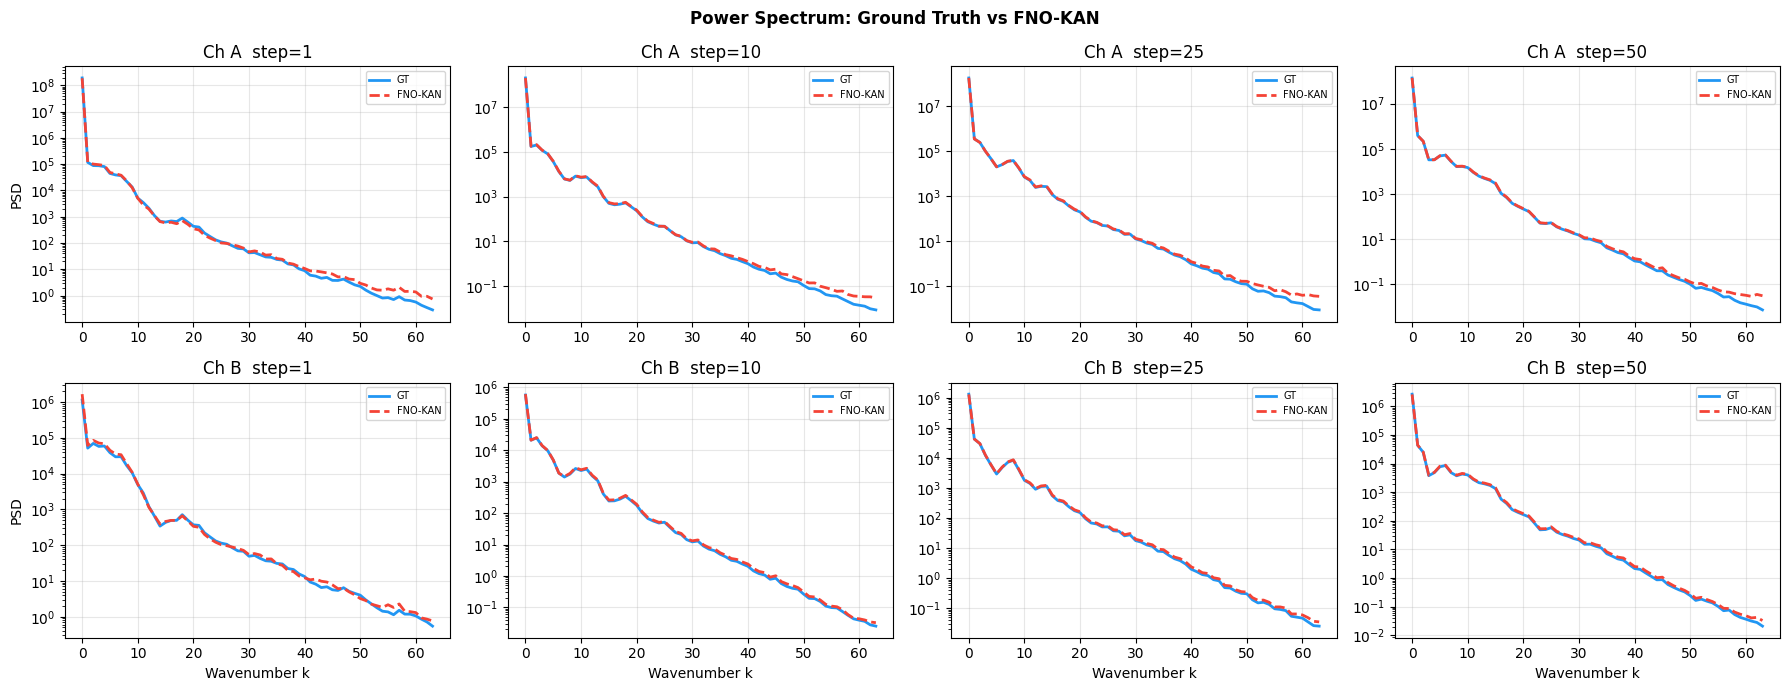

In [ ]:
# Cell 18: Power spectrum analysis

def radial_psd(field):
    ft  = np.fft.fft2(field)
    psd = np.abs(np.fft.fftshift(ft))**2
    H, W = psd.shape
    cy, cx = H//2, W//2
    R = np.sqrt((np.arange(H)[:,None]-cy)**2 +
                (np.arange(W)[None,:]-cx)**2).astype(int)
    radial = np.bincount(R.ravel(), psd.ravel()) / (np.bincount(R.ravel()) + 1e-12)
    return radial[:min(H,W)//2]


snap_steps = [0, 9, 24, 49]
fig, axes  = plt.subplots(2, len(snap_steps), figsize=(18, 7))
fig.suptitle('Power Spectrum: Ground Truth vs FNO-KAN', fontsize=12, fontweight='bold')

for col, step in enumerate(snap_steps):
    if step >= len(test_preds): continue
    for row, ch in enumerate([0, 1]):
        psd_p = radial_psd(test_preds[step, ch])
        psd_t = radial_psd(test_trues[step, ch])
        ax = axes[row, col]
        ax.semilogy(range(len(psd_t)), psd_t, label='GT',      color='#2196F3', lw=2)
        ax.semilogy(range(len(psd_p)), psd_p, label='FNO-KAN', color='#F44336', lw=2, ls='--')
        ax.set_title(f'Ch {"AB"[ch]}  step={step+1}')
        if col == 0: ax.set_ylabel(f'PSD')
        if row == 1: ax.set_xlabel('Wavenumber k')
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/power_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Cell 19: Gate analysis -- dual-domain head interpretability

gate_a = torch.tanh(model.dual_head.gate_a).item()
gate_b = model.dual_head.gate_b.item()
total_g = abs(gate_a) + abs(gate_b)
print('='*55)
print('Dual-domain gate values:')
print(f'  gate_a (spectral KAN) : tanh = {gate_a:.4f}')
print(f'  gate_b (spatial conv) :       {gate_b:.4f}')
print(f'  Spectral contribution : {100*abs(gate_a)/total_g:.1f}%')
print(f'  Spatial  contribution : {100*abs(gate_b)/total_g:.1f}%')
print('\nFor Gray-Scott maze (locally dominated PDE),')
print('we expect gate_b > gate_a (spatial > spectral).')
print('Large gate_a means the KAN is capturing the AB^2 reaction spectrally.')


Dual-domain gate values:
  gate_a (spectral KAN) : tanh = 0.0178
  gate_b (spatial conv) :       0.8121
  Spectral contribution : 2.2%
  Spatial  contribution : 97.8%

For Gray-Scott maze (locally dominated PDE),
we expect gate_b > gate_a (spatial > spectral).
Large gate_a means the KAN is capturing the AB^2 reaction spectrally.


In [ ]:
# Cell 20: Save full results summary

results = {
    'model'           : 'Dual-Domain FNO-KAN',
    'dataset'         : 'gray_scott_reaction_diffusion / maze',
    'n_params'        : sum(p.numel() for p in model.parameters() if p.requires_grad),
    'train_pairs'     : len(train_ds),
    'val_pairs'       : len(val_ds),
    'test_pairs'      : len(test_ds),
    'best_val_rl2'    : float(best_val),
    'test_metrics'    : {k: float(v) for k, v in metrics.items()},
    'fno_baseline'    : 0.1365,
    'delta_vs_baseline': float(metrics['VRMSE'] - 0.1365),
    'rollout'         : {
        'steps_below_05': int(sum(e < 0.5 for e in ro_errors)),
        'total_steps'   : len(ro_errors),
        'final_error'   : float(ro_errors[-1]),
    },
    'gate_analysis'   : {
        'gate_a_tanh': float(torch.tanh(model.dual_head.gate_a).item()),
        'gate_b'     : float(model.dual_head.gate_b.item()),
    },
    'config'          : {
        'width': WIDTH, 'modes': MODES, 'n_fno_layers': N_FNO_LAYERS,
        'kan_hidden': KAN_HIDDEN, 'kan_grid': KAN_GRID, 'kan_order': KAN_ORDER,
        'lr': LR, 'weight_decay': WEIGHT_DECAY, 'spectral_wt': SPECTRAL_WT,
        'num_epochs': NUM_EPOCHS, 'patience': PATIENCE,
    },
}

save_path = f'{BASE_DIR}/results_dual_fno_kan.json'
with open(save_path, 'w') as fp:
    json.dump(results, fp, indent=2)

print('='*55)
print('  FINAL RESULTS SUMMARY')
print('='*55)
print(f'  Parameters : {results["n_params"]:,}')
print(f'  Test VRMSE : {metrics["VRMSE"]:.4f}')
print(f'  FNO base   : 0.1365')
print(f'  Delta      : {metrics["VRMSE"]-0.1365:+.4f}')
print(f'  Rollout    : {results["rollout"]["steps_below_05"]}/{results["rollout"]["total_steps"]} steps below 0.5')
print(f'\nOutputs saved to: {BASE_DIR}/')
print('  dual_fno_kan_best.pt')
print('  results_dual_fno_kan.json')
print('  training_curves.png')
print('  predictions.png')
print('  rollout_curve.png')
print('  power_spectrum.png')


  FINAL RESULTS SUMMARY
  Parameters : 2,063,748
  Test VRMSE : 0.0136
  FNO base   : 0.1365
  Delta      : -0.1229
  Rollout    : 50/50 steps below 0.5

Outputs saved to: /content/drive/MyDrive/gray_scott_data/
  dual_fno_kan_best.pt
  results_dual_fno_kan.json
  training_curves.png
  predictions.png
  rollout_curve.png
  power_spectrum.png
